### Imports

In [ ]:
import pickle
from PIL import Image
from vit import tinyViT
import matplotlib.pyplot as plt
import torch
import numpy as np
from hydra import initialize, compose
from vit import tinyViT
from torchvision import transforms
from omegaconf import DictConfig

### Definitions

In [48]:
video_file = "./video_frames.pkl"
goal_file = "./goal_frame.pkl"

with open(video_file, "rb") as file:
    frames = pickle.load(file)
with open(goal_file, "rb") as file:
    goal_frame = pickle.load(file)[0];

def bytes_to_image(frame):
    image = np.frombuffer(frame, dtype=np.uint8)
    image = image.reshape((64, 64, 3)) # 540, 952
    image = Image.fromarray(image, "RGB")

    return image

def new_vit(cfg: DictConfig):
    checkpoint = torch.load('./best_model.pt', weights_only=True, map_location="cpu")
    vit_weights = checkpoint["model_state_dict"]

    vit_weights = {k.replace("encoder.", ""): v for k, v in vit_weights.items() if k.startswith("encoder.")}

    vit = tinyViT( 
        image_size=cfg.vit.image_size,
        patch_size=cfg.vit.patch_size,
        embedding_dim=cfg.vit.embedding_dim,
        num_channels=cfg.vit.num_channels,
        num_patches=cfg.vit.num_patches,
        attention_heads=cfg.vit.attention_heads,
        mlp_hidden_nodes=cfg.vit.mlp_hidden_nodes,
        transformer_blocks=cfg.vit.transformer_blocks
    )
    vit.load_state_dict(vit_weights, strict=False)
    vit.eval()

    return vit

### Display goal frame

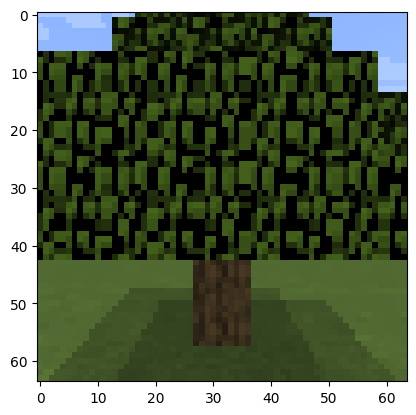

In [49]:
plt.imshow(bytes_to_image(goal_frame));

### Create embeddings

In [50]:
with initialize(config_path="./config"):
    cfg = compose(config_name="lewm")

vit = new_vit(cfg)
embeddings = []

def process_frame_pixels(frame, vit):
    transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])

    img_t = transform(bytes_to_image(frame)).unsqueeze(0)

    with torch.no_grad():
        embed = vit(img_t)

    return embed

def run_vit(model):
    for frame in frames:
        embeddings.append(process_frame_pixels(frame, model))
    
run_vit(vit)
goal_embed = process_frame_pixels(goal_frame, vit)
print(len(embeddings))

C:\Users\alexa\AppData\Local\Temp\ipykernel_26316\3985130893.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="./config"):


192
18


### Collect embedding similarities

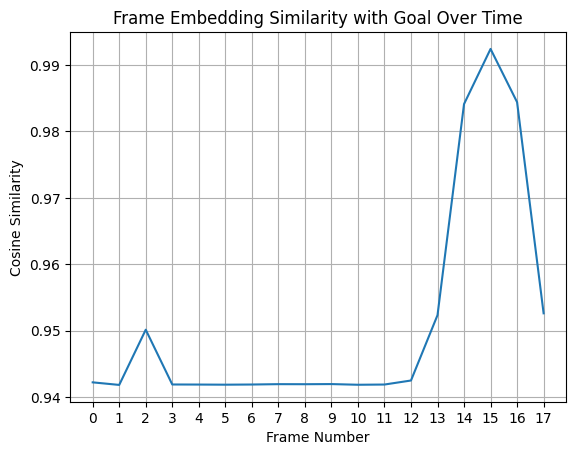

In [ ]:
similarities = []
goal = goal_embed[0].flatten()

for embed in embeddings:
    embed = embed[0].flatten()
    similarities.append(torch.nn.functional.cosine_similarity(goal, embed, dim=0).item())

plt.plot(similarities)
plt.xlabel("Frame Number")
plt.xticks(range(len(similarities)))
plt.ylabel("Cosine Similarity")
plt.title("Frame Encoding Similarity with Goal Over Time")
plt.grid()
plt.show()

### Display local maximums

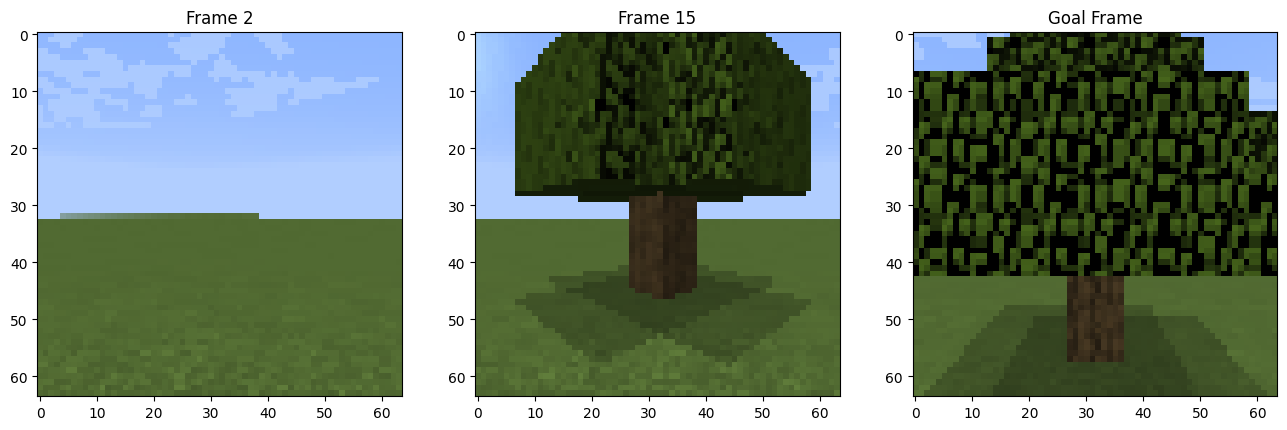

In [52]:
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(16, 5)

axes[0].imshow(bytes_to_image(frames[2]))
axes[0].set_title("Frame 2")
axes[1].imshow(bytes_to_image(frames[15]))
axes[1].set_title("Frame 15")
axes[2].imshow(bytes_to_image(goal_frame))
axes[2].set_title("Goal Frame")

plt.show()

Since frame 2 doesn't bear as much resemblance to the goal frame, we might want to have a threshold value of around 0.98 for superflat worlds.